In [1]:
# Pandas data handling ke liye
import pandas as pd

# Dataset directly IBM ke public GitHub repository se load kar rahe hain
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

# First 5 rows dekho
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# lets check the shape of the data
df.shape

(7043, 21)

In [3]:
#understand the data
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


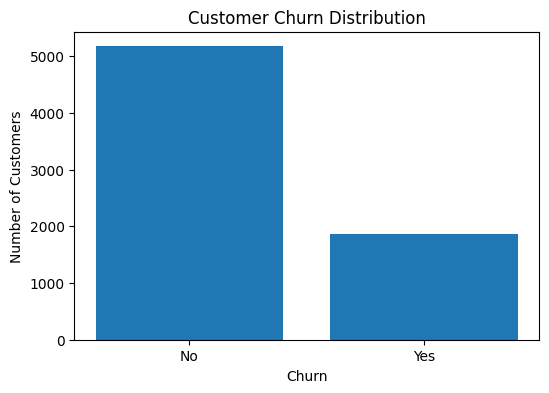

In [8]:
# lets visualize the churn
import matplotlib.pyplot as plt

# Churn ki counting
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")

plt.show()

In [9]:
# chrun percentage
churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


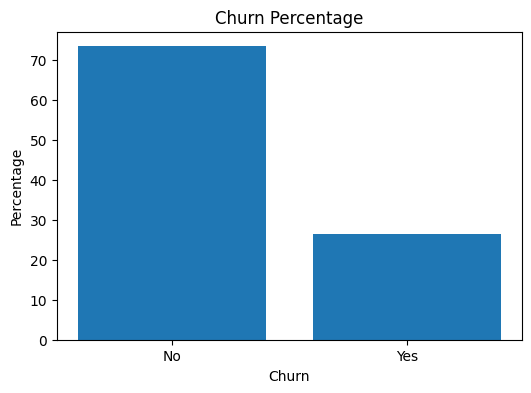

In [10]:
# lets visualize it
plt.figure(figsize=(6, 4))

plt.bar(
    churn_percentage.index,
    churn_percentage.values
)

plt.xlabel("Churn")
plt.ylabel("Percentage")
plt.title("Churn Percentage")

plt.show()

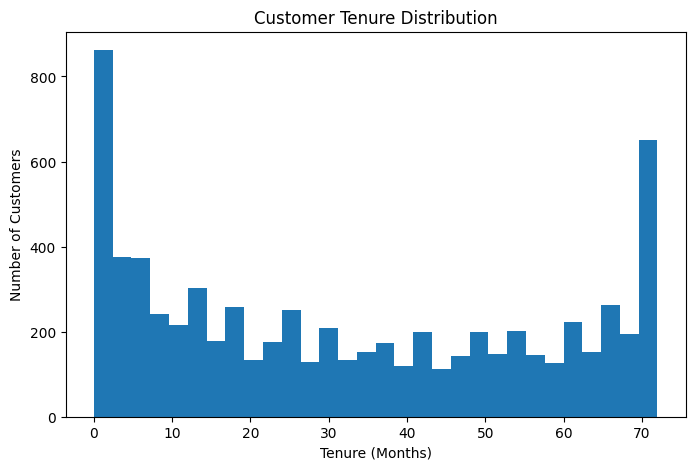

In [13]:
# lets visulize the numerical features
plt.figure(figsize=(8, 5))

plt.hist(df['tenure'], bins=30)

plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.title("Customer Tenure Distribution")

plt.show()

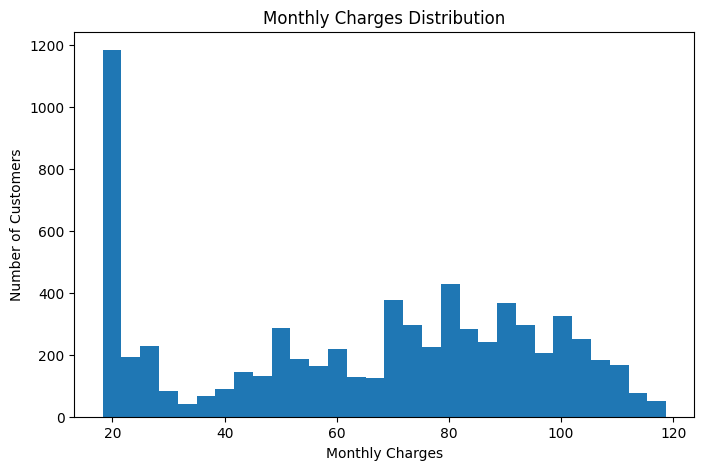

In [14]:
# monthly charges
plt.figure(figsize=(8, 5))

plt.hist(df['MonthlyCharges'], bins=30)

plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.title("Monthly Charges Distribution")

plt.show()

/tmp/ipykernel_5462/3993597734.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


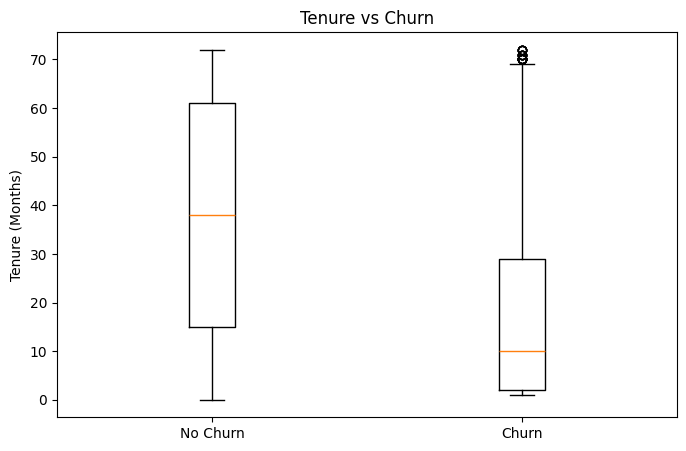

In [15]:
# churn vs tenure
# k kitne months wale customers chor k ja rahe ha
# Churn ko numerical banane ke liye temporary column
df['ChurnNumeric'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df['ChurnNumeric'] == 0]['tenure'],
        df[df['ChurnNumeric'] == 1]['tenure']
    ],
    labels=['No Churn', 'Churn']
)

plt.ylabel("Tenure (Months)")
plt.title("Tenure vs Churn")

plt.show()

In [16]:
# means k start wale customers chor k ja rahe ha , but jo aik bar custoemr ban jaey wo
# fir hamare sath hi hai
# gotta find a way to reduce this churn rate, maybe comapny ko more engaging stuff
# krna chahie start me hi


In [17]:
# contract vs churn
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


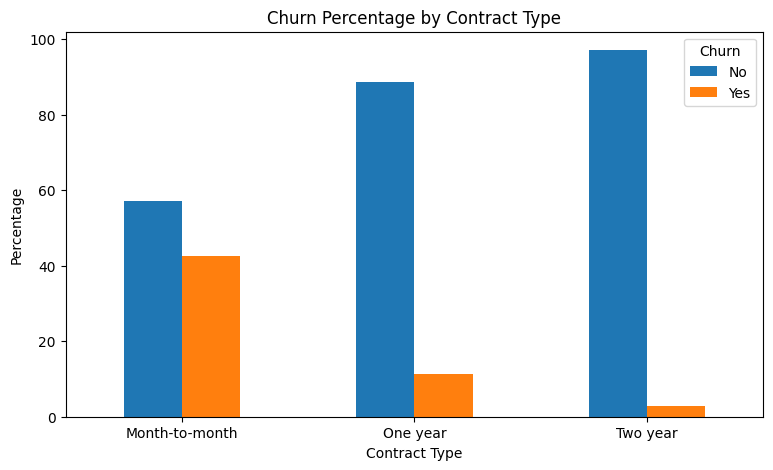

In [19]:
contract_churn.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.title("Churn Percentage by Contract Type")

plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()
# month by month walo ka churn kafi zyada ha


In [20]:
# data cleaning - as we have understood the data
# we do not need the cusotmer id
df = df.drop('customerID', axis=1)

In [21]:
df.head()
# convert total charges to numeric

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnNumeric
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [22]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [23]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [29]:
print(df['TotalCharges'].head())
print(df.shape)


0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64
(7032, 21)


In [30]:
# drop the missing rows
df = df.dropna()
print(df['TotalCharges'].head())
print(df.shape)

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64
(7032, 21)


In [31]:
# separate the target
X = df.drop('Churn', axis=1)

y = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

In [32]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,ChurnNumeric
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


In [33]:
y

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [34]:
# ann do not understand the strings
# so we have ot make all the data numerical
X = pd.get_dummies(
    X,
    drop_first=True
)

In [35]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
# stratify=y

# Ye important hai.

# Ye ensure karta hai ke train/test mein churn classes ka proportion approximately maintain rahe.

# Original
#    ↓
# Train 80%
# Test  20%

In [39]:
# scaling karte ha ta k sab input aik hi scale pe ajae
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [40]:
# lets use tf and keras to make the ann
import tensorflow as tf

model = tf.keras.Sequential([

    # First hidden layer
    tf.keras.layers.Dense(
        16,
        activation='relu'
    ),

    # Second hidden layer
    tf.keras.layers.Dense(
        8,
        activation='relu'
    ),

    # Output layer
    # Binary classification → 1 neuron
    # Sigmoid → probability between 0 and 1
    tf.keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])

In [42]:
# Input
#   │
#   ▼
# Dense(16)
# ReLU
#   │
#   ▼
# Dense(8)
# ReLU
#   │
#   ▼
# Dense(1)
# Sigmoid
#   │
#   ▼
# Churn Probability

In [43]:
# compile the neural network
model.compile(

    # Optimizer weights update karega
    optimizer='adam',

    # Binary classification ke liye
    loss='binary_crossentropy',

    # Accuracy track karenge
    metrics=['accuracy']
)

In [44]:
# train the model
history = model.fit(

    X_train,
    y_train,

    # Dataset kitni baar network ko dikhana hai
    epochs=50,

    # Ek batch mein kitne samples
    batch_size=32,

    # Training data ka 20% validation
    validation_split=0.2,

    # Output ko readable rakhta hai
    verbose=1
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8238 - loss: 0.4450 - val_accuracy: 0.9324 - val_loss: 0.2749
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9696 - loss: 0.1509 - val_accuracy: 0.9956 - val_loss: 0.0516
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9978 - loss: 0.0304 - val_accuracy: 1.0000 - val_loss: 0.0134
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9996 - loss: 0.0102 - val_accuracy: 1.0000 - val_loss: 0.0058
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9996 - loss: 0.0050 - val_accuracy: 1.0000 - val_loss: 0.0036
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.

In [45]:
# slightly overfit ho gaya 20 , 30 epoch me b chal jata

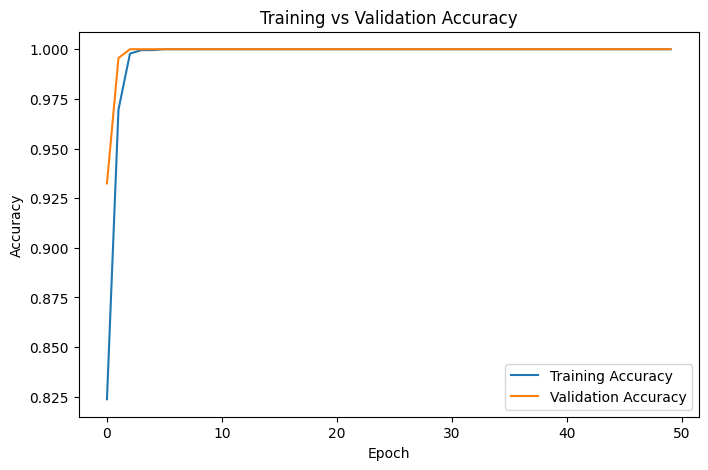

In [46]:
# accuracy graph
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

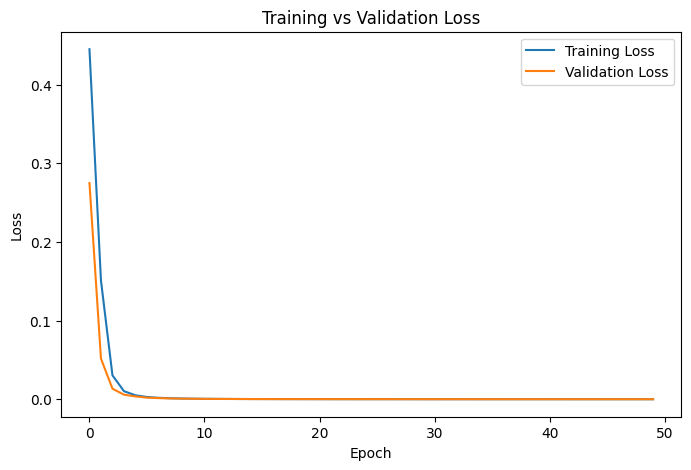

In [47]:
# loss graph
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [48]:
# test accuracy
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 7.642611308256164e-06
Test Accuracy: 1.0


In [49]:
# wow 100% - hehehe

In [50]:
# lets do the predictions
# Model probabilities predict karega
y_prob = model.predict(X_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [51]:
# classes
y_pred = (y_prob >= 0.5).astype(int)

In [52]:
# confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[1033    0]
 [   0  374]]


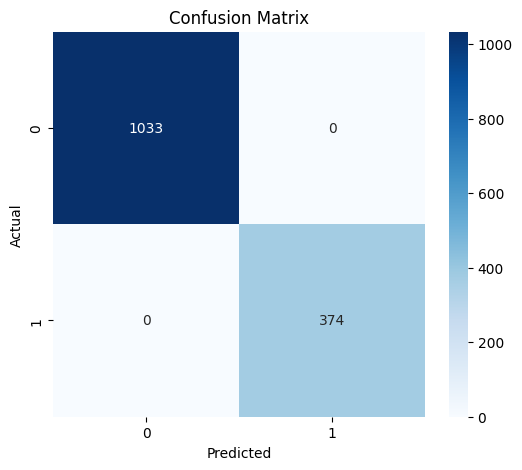

In [53]:
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [55]:
# TN  FP FN TP

In [56]:
# classification report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1033
           1       1.00      1.00      1.00       374

    accuracy                           1.00      1407
   macro avg       1.00      1.00      1.00      1407
weighted avg       1.00      1.00      1.00      1407



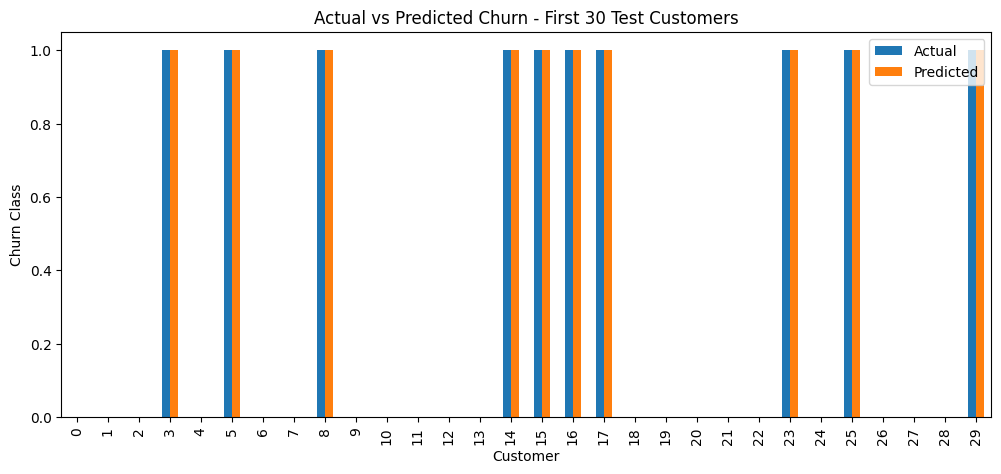

In [57]:
# actual vs prediction
comparison = pd.DataFrame({
    'Actual': y_test.values[:30],
    'Predicted': y_pred.flatten()[:30]
})

comparison.plot(
    kind='bar',
    figsize=(12, 5)
)

plt.xlabel("Customer")
plt.ylabel("Churn Class")
plt.title("Actual vs Predicted Churn - First 30 Test Customers")

plt.legend()

plt.show()

In [59]:
# ab agar model ko real customer de to
sample_customer = X_test[0].reshape(1, -1)

probability = model.predict(sample_customer)[0][0]

print("Churn Probability:", probability)

if probability >= 0.5:
    print("Prediction: Customer may churn")
else:
    print("Prediction: Customer may stay")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Churn Probability: 2.1230057e-06
Prediction: Customer may stay


In [ ]:
      #            IBM TELCO DATASET
      #                  │
      #                  ▼
      #          7,043 Customers
      #                  │
      #                  ▼
      #         Data Exploration
      #                  │
      #     ┌────────────┼────────────┐
      #     ▼            ▼            ▼
      #  Churn        Tenure       Charges
      # Graph          Graph         Graph
      #     │            │            │
      #     └────────────┼────────────┘
      #                  ▼
      #              Cleaning
      #                  │
      #                  ▼
      #             Encoding
      #                  │
      #                  ▼
      #           Train / Test
      #                  │
      #                  ▼
      #               Scaling
      #                  │
      #                  ▼
      #           ┌────────────┐
      #           │    ANN     │
      #           │            │
      #           │ 16 ReLU    │
      #           │     ↓      │
      #           │  8 ReLU    │
      #           │     ↓      │
      #           │ 1 Sigmoid  │
      #           └─────┬──────┘
      #                 │
      #                 ▼
      #           Churn Probability
      #                 │
      #        ┌────────┴────────┐
      #        ▼                 ▼
      #    Accuracy             Loss
      #     Graph               Graph
      #        │                 │
      #        └────────┬────────┘
      #                 ▼
      #           Test Predictions
      #                 │
      #                 ▼
      #          Confusion Matrix
      #                 │
      #                 ▼
      #        Classification Report
      #                 │
      #                 ▼
      #        Individual Prediction